# Multi-Goal Financial Asset Recommender System

**RL-Driven Transformer Pipeline:**
- **[PHASE 1 — Member A] Autoencoder Embeddings**: Trains a masked weighted autoencoder on ALL historical data with exponential time-decay weighting. Produces compressed 8-dimensional behavioral embeddings per asset.
- **[PHASE 2–3 — Member D] RL Transformer + Gaussian Policy**: A Transformer processes the entire market universe via Self-Attention. A Gaussian Policy head outputs (μ, σ) per asset — target allocation and exploration noise.
- **[PHASE 4–5 — Member D + C] Simulator Environment + REINFORCE**: Sampled weights are passed into the non-differentiable simulator. An inverse-exponential reward is returned. The Policy Gradient theorem updates the Transformer without needing gradients through the simulator.

### Architecture
All function definitions live in worker modules (`_*.py`). This notebook is a **thin orchestration layer** — edit `_constants.py` for config, dive into workers for implementation details.

In [1]:
%pip install yfinance matplotlib seaborn scipy lxml html5lib requests tqdm nbformat torch
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


## Phase 1 — Member A: Data Scraping & Autoencoder Embeddings

In [2]:
# ── Configure Pipeline ──
from _constants import DEFAULT_PIPELINE_CONFIG, DataSyncMode
config = DEFAULT_PIPELINE_CONFIG.copy()
config["data_source_mode"] = DataSyncMode.OFFLINE_CSV_ONLY  # Override for this run

# ADDING THESE CONFIGS FOR STOP/STARTING
# config["ml_resume_mode"] = "auto"          # auto = resume if checkpoint exists
# config["ml_cache_dir"] = "cache"
config["ml_checkpoint_frequency"] = 1      # save every epoch


# ── Fetch Universe & Build Dataset ──
from _data_worker import fetch_macro_universe, generate_dataset_member_a, run_data_diagnostics

tickers = fetch_macro_universe() if config["data_source_mode"] != DataSyncMode.OFFLINE_CSV_ONLY else []
master_df, price_matrix, volume_matrix, daily_returns, drip_returns = generate_dataset_member_a(tickers, config)

# ── Validate Data Quality ──
run_data_diagnostics(master_df, config)

[21:34:03] [Member A] Booting in mode [OFFLINE_CSV_ONLY]

[21:34:06] [Member A] Preprocessing Configured ML Features...
   -> WARNING: Requested config feature 'sector' not found in master_df.
   -> WARNING: Requested config feature 'industry' not found in master_df.
   -> WARNING: Requested config feature 'state' not found in master_df.
   -> WARNING: Requested config feature 'quoteType' not found in master_df.
   -> WARNING: Requested config feature 'exchange' not found in master_df.

=== DATAFRAME DIAGNOSTICS & SYSTEM MAPPING ===
Total Equities Tracked: 6426
Total Columns Processed per Asset: 414

All Features Extracted in Master DF:
['address1', 'city', 'zip', 'country', 'phone', 'website', 'industryKey', 'industryDisp', 'sectorKey', 'sectorDisp', 'longBusinessSummary', 'fullTimeEmployees', 'companyOfficers', 'auditRisk', 'boardRisk', 'compensationRisk', 'shareHolderRightsRisk', 'overallRisk', 'governanceEpochDate', 'compensationAsOfEpochDate', 'irWebsite', 'executiveTeam', 'maxAge

In [4]:
# ── Train Embedding Model ──
from _ml_worker import train_pytorch_embedding_model

DATA_CACHE = train_pytorch_embedding_model(
    master_df, price_matrix, volume_matrix, daily_returns,
    config,
    drip_daily_returns=drip_returns
)

[22:02:58] [Member A] Initializing Dual-Head Sequence Transformer...
  [Member A] Excluding 'FUMB': Insufficient history (2139 days < 5040)
  [Member A] Excluding 'MART': Insufficient history (2139 days < 5040)
  [Member A] Excluding 'CARG': Insufficient history (2139 days < 5040)
  [Member A] Excluding 'ASCI': Insufficient history (2139 days < 5040)
  [Member A] Excluding 'FICS': Insufficient history (2139 days < 5040)
  [Member A] Temporal Split Cutoff: 2006-12-31
  [Member A] Train Samples: 258614 (Pre-2006)
  [Member A] Val Samples:   128420 (2006+)
[22:07:10] [Member A] Training 258614 limit: 1260 tokens / Valid 128420. (Device: cuda)
  [Member A] Resume Mode: Loading checkpoint for ed8_dm64_lr001 from 'cache\checkpoint_ed8_dm64_lr001.pt'...
  [Member A] Successfully resumed from Epoch 2. Previous Best Val Loss: 2.6551


[22:48:18] [Member A] Saving Checkpoint.


[23:30:20] [Member A] Saving Checkpoint.


[00:12:46] [Member A] Saving Checkpoint.


[00:35:54] [Member A] Saving Checkpoint.


...

[09:26:49] [Member A] Saving Checkpoint.


[09:49:22] [Member A] Saving Checkpoint.


[10:11:58] Epoch 30/150 | Train Dual-Loss: 0.0890 | Val Loss: 2.6577
[10:11:58] [Member A] Saving Checkpoint.


[10:34:42] [Member A] Saving Checkpoint.


[10:57:14] [Member A] Saving Checkpoint.
[10:57:14] Early stopping triggered at epoch 32
[10:58:17] [Member A] Generated dynamic sequence embeddings for 6421 assets.
[10:58:17] [Member A] Persistence: Results and model saved to 'cache/ed8_dm64_lr001'


## Phases 2–5 — Member D: End-to-End RL Transformer Portfolio Optimizer

**Replaces the old Member B/C scoring pipeline** with an End-to-End Reinforcement Learning system.

In [5]:
# ── Multi-Profile RL Transformer (Curriculum Learning) ──
import importlib
import _rl_worker, _sim_worker, _constants
importlib.reload(_constants)
importlib.reload(_sim_worker)
importlib.reload(_rl_worker)
from _rl_worker import train_rl_agent
from _constants import TEST_PROFILES
import pandas as pd
from IPython.display import display

# We define the Curriculum Order: Aggressive -> Balanced -> Conservative
curriculum_order = ["Aggressive Young Investor", "Balanced Growth (House + Retirement)", "Conservative Retiree"]
sorted_profiles = sorted(TEST_PROFILES, key=lambda x: curriculum_order.index(x['profile_name']) if x['profile_name'] in curriculum_order else 99)

all_profile_results = []
global_agent = None  # Persistent agent for warm-starts

for profile in sorted_profiles:
    print("\n" + "═" * 80)
    print(f"  PROFILE: {profile['profile_name']}")
    print(f"  Start Capital: ${profile['start_cap']:,.0f} | Risk: {profile['risk_tolerance']}")
    print(f"  Active Goals:")
    for yr, amt in sorted(profile['goals'].items()):
        print(f"    - Year {yr:<2}: ${amt:,.0f}")
    print("═" * 80)

    # Train using Warm-Start logic (and enable visual simulation debugger for final step)
    rl_results = train_rl_agent(DATA_CACHE, profile, config, existing_agent=global_agent, verbose=True, debug_sim=True)
    global_agent = rl_results.get('agent')  # Pass this to the next profile

    final_reward = rl_results.get('final_reward', 0.0)
    history = rl_results.get('training_history', [])
    final_portfolio = rl_results.get('portfolio_weights', {})
    policy_params = rl_results.get('policy_params', {})

    final_episode = history[-1] if history else {}
    print(f"\n  ─── FINAL SIMULATION RESULTS ───")
    print(f"  Selected Assets:             {len(final_portfolio)}")
    print(f"  Goal Fulfillment Rate (GFR): {final_episode.get('GFR', 0):.2%}")
    print(f"  Expected Terminal Value:     ${final_episode.get('ETV', 0):,.0f}")
    print(f"  Final Scalar Reward:         {final_reward:.4f}")

    if len(final_portfolio) > 0:
        print(f"\n  ─── FULL PORTFOLIO ALLOCATION ───")
        print(f"    {'Ticker':<10} {'Weight':<10} {'μ (Target)':<12} {'σ (Explor)':<12}")
        print(f"    {'-'*45}")
        # Sort by weight descending
        all_assets = sorted(final_portfolio.items(), key=lambda x: x[1], reverse=True)
        for ticker, weight in all_assets:
            params = policy_params.get(ticker, {'mu': 0, 'sigma': 0})
            print(f"    {ticker:<10} {weight:<10.2%} {params['mu']:<12.4f} {params['sigma']:<12.4f}")

    all_profile_results.append({
        "Profile": profile["profile_name"],
        "Assets": len(final_portfolio),
        "GFR": f"{final_episode.get('GFR', 0):.2%}",
        "ETV": f"${final_episode.get('ETV', 0):,.0f}",
        "Reward": f"{final_reward:.4f}"
    })

display(pd.DataFrame(all_profile_results))


════════════════════════════════════════════════════════════════════════════════
  PROFILE: Aggressive Young Investor
  Start Capital: $50,000 | Risk: 9.0
  Active Goals:
    - Year 15: $80,000
    - Year 30: $200,000
════════════════════════════════════════════════════════════════════════════════
[16:08:22] [Member D] Starting RL Training Loop for 1000 episodes...

  [SIMULATOR DEBUG] Parallel Mode: ON | Cores: 20 | Available Data: 12 years | Goal Horizon: 30 years
    Path 2015 (Horizon 12): Y1: $50,870 (+1.7%) -> Y2: $60,044 (+18.0%) -> Y3: $73,691 (+22.7%) -> Y4: $69,293 (-6.0%) -> Y5: $88,560 (+27.8%) -> Y6: $142,058 (+60.4%) -> Y7: $181,810 (+28.0%) -> Y8: $159,055 (-12.5%) -> Y9: $190,205 (+19.6%) -> Y10: $217,068 (+14.1%) -> Y11: $251,790 (+16.0%) -> Y12: $269,750 (+7.1%) ✅
    Path 2016 (Horizon 11): Y1: $59,016 (+18.0%) -> Y2: $72,431 (+22.7%) -> Y3: $68,108 (-6.0%) -> Y4: $87,045 (+27.8%) -> Y5: $139,628 (+60.4%) -> Y6: $178,700 (+28.0%) -> Y7: $156,334 (-12.5%) -> Y8: $186

,Profile,Assets,GFR,ETV,Reward
0,Aggressive Young Investor,51,100.00%,"$187,937",0.1646
1,Balanced Growth (House + Retirement),45,100.00%,"$323,943",0.2055
2,Conservative Retiree,54,100.00%,"$957,110",0.4786


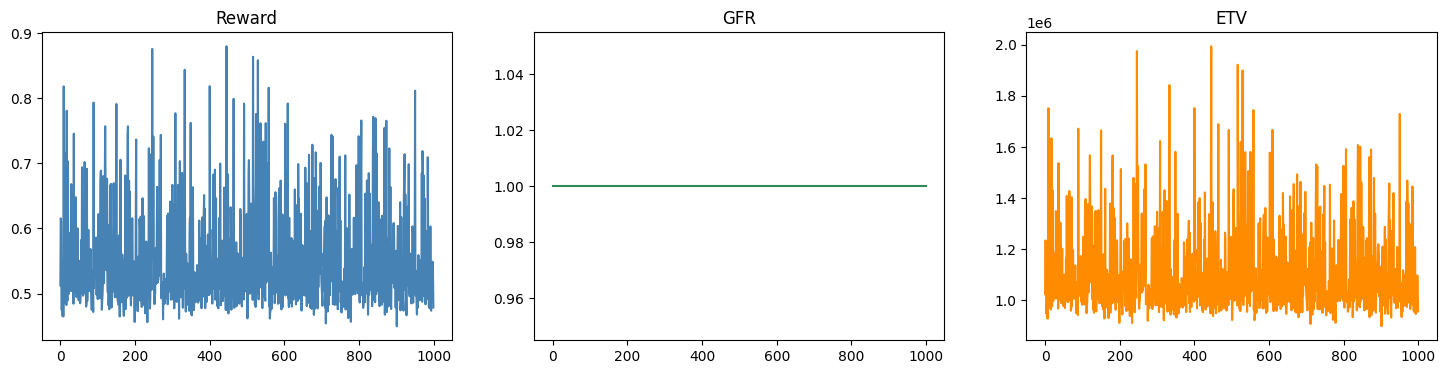

In [6]:
# ── Reward Convergence Plot ──
if 'history' in locals() and history:
    episodes = [h['episode'] for h in history]
    rewards  = [h['reward'] for h in history]
    gfrs     = [h['GFR'] for h in history]
    etvs     = [h['ETV'] for h in history]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(episodes, rewards, color='steelblue')
    axes[0].set_title('Reward')
    axes[1].plot(episodes, gfrs, color='seagreen')
    axes[1].set_title('GFR')
    axes[2].plot(episodes, etvs, color='darkorange')
    axes[2].set_title('ETV')
    plt.show()